# Taller 2 — Implementación de un agente DQN

##Implementación del agente Deep Q-Network

Este notebook presenta la implementación de un agente **Deep Q-Network (DQN)** para resolver el ambiente `LunarLander-v3` de Gymnasium.

En esta etapa se desarrolla la estructura principal del agente, incluyendo la red neuronal para aproximar la función Q, el almacenamiento de experiencias mediante Replay Buffer, la política epsilon-greedy y la utilización de una Target Network.

In [1]:
!pip install "gymnasium[box2d]" torch torchvision torchaudio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 33.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 49.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 74.4 MB/s eta 0:00:00


##Importaciones

In [2]:
import gymnasium as gym
import numpy as np
import random
from collections import deque

import torch
import torch.nn as nn
import torch.optim as optim

## 1. Configuración del ambiente

En esta sección se configura el ambiente `LunarLander-v3` y se obtienen las dimensiones de los espacios de observación y acción.

El ambiente cuenta con un vector de observaciones de 8 variables y un espacio de acciones discreto compuesto por 4 acciones. Estas dimensiones serán utilizadas posteriormente para definir la entrada y salida de la red neuronal del agente DQN.

In [3]:
# Crear el ambiente
env = gym.make("LunarLander-v3")

# Obtener dimensiones del ambiente
state_size = env.observation_space.shape[0]
action_size = env.action_space.n

print("Dimensión del estado:", state_size)
print("Número de acciones:", action_size)

env.close()

Dimensión del estado: 8
Número de acciones: 4


## 2. Arquitectura de la red neuronal

La red neuronal utilizada por el agente DQN tiene como objetivo aproximar la función de valor **Q(s,a)**. Esta función estima la recompensa acumulada esperada para cada acción posible a partir de un estado determinado.

Debido a que `LunarLander-v3` presenta 8 variables de observación y 4 acciones discretas, la red recibe un vector de entrada de 8 características y genera 4 valores de salida, uno por cada acción disponible.

La arquitectura propuesta está compuesta por dos capas ocultas de 128 neuronas cada una, utilizando la función de activación ReLU. La capa de salida no utiliza una función de activación, ya que sus valores representan directamente las estimaciones Q para cada acción.

La arquitectura es:

**8 → 128 → 128 → 4**

Esta estructura proporciona suficiente capacidad para aprender relaciones no lineales entre el estado de la nave y las acciones disponibles, manteniendo al mismo tiempo una arquitectura relativamente sencilla para facilitar el entrenamiento.

In [4]:
class DQN(nn.Module):
    def __init__(self, state_size, action_size):
        super(DQN, self).__init__()

        self.network = nn.Sequential(
            nn.Linear(state_size, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, action_size)
        )

    def forward(self, state):
        return self.network(state)

In [5]:
# Crear la red neuronal
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

q_network = DQN(state_size, action_size).to(device)

print(q_network)
print("\nDispositivo utilizado:", device)

DQN(
  (network): Sequential(
    (0): Linear(in_features=8, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=4, bias=True)
  )
)

Dispositivo utilizado: cpu


## 3. Replay Buffer

El Replay Buffer permite almacenar las experiencias obtenidas por el agente durante la interacción con el ambiente.

Cada experiencia está compuesta por:

- Estado actual `state`
- Acción seleccionada `action`
- Recompensa obtenida `reward`
- Estado siguiente `next_state`
- Indicador de terminación `done`

Durante el entrenamiento, el agente no utiliza las experiencias únicamente en el orden en que fueron generadas. En su lugar, selecciona aleatoriamente un conjunto de experiencias almacenadas. Este mecanismo, conocido como **Experience Replay**, ayuda a reducir la correlación entre muestras consecutivas y mejora la estabilidad del aprendizaje.

Para este proyecto se utilizará una capacidad máxima de **100.000 experiencias**.

In [6]:
class ReplayBuffer:
    def __init__(self, capacity=100000):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append(
            (state, action, reward, next_state, done)
        )

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)

        states, actions, rewards, next_states, dones = zip(*batch)

        return (
            np.array(states, dtype=np.float32),
            np.array(actions, dtype=np.int64),
            np.array(rewards, dtype=np.float32),
            np.array(next_states, dtype=np.float32),
            np.array(dones, dtype=np.float32)
        )

    def __len__(self):
        return len(self.buffer)

In [7]:
# Crear el Replay Buffer
replay_buffer = ReplayBuffer(capacity=100000)

print("Capacidad máxima:", replay_buffer.buffer.maxlen)
print("Experiencias almacenadas inicialmente:", len(replay_buffer))

Capacidad máxima: 100000
Experiencias almacenadas inicialmente: 0


## 4. Política epsilon-greedy

La política **epsilon-greedy** permite controlar el equilibrio entre exploración y explotación durante el entrenamiento.

Con una probabilidad `epsilon`, el agente selecciona una acción de manera aleatoria para explorar nuevas posibilidades. En el resto de los casos, selecciona la acción que actualmente presenta el mayor valor Q estimado por la red neuronal.

Al inicio del entrenamiento se utiliza un valor alto de `epsilon`, favoreciendo la exploración. A medida que avanza el entrenamiento, `epsilon` disminuye gradualmente, permitiendo que el agente aproveche con mayor frecuencia el conocimiento aprendido.

Para este proyecto se utilizará una tasa de exploración inicial de `1.0`, un valor mínimo de `0.01` y un factor de decaimiento de `0.995`.

In [8]:
# Hiperparámetros de epsilon-greedy
epsilon = 1.0
epsilon_min = 0.01
epsilon_decay = 0.995

def select_action(state, q_network, epsilon):
    # Exploración
    if random.random() < epsilon:
        return random.randrange(action_size)

    # Explotación
    state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)

    with torch.no_grad():
        q_values = q_network(state_tensor)

    return q_values.argmax(dim=1).item()

In [9]:
# Probar selección de acción
env = gym.make("LunarLander-v3")
state, info = env.reset(seed=42)

action = select_action(state, q_network, epsilon)

print("Estado:", state)
print("Acción seleccionada:", action)
print("Epsilon actual:", epsilon)

env.close()

Estado: [ 0.00229702  1.4181306   0.2326471   0.3204666  -0.00265488 -0.05269805
  0.          0.        ]
Acción seleccionada: 0
Epsilon actual: 1.0


## 5. Target Network y actualización de la función Q

El agente DQN utiliza dos redes neuronales con la misma arquitectura:

- **Q-Network:** se actualiza durante el entrenamiento y representa la estimación actual de los valores Q.
- **Target Network:** proporciona una estimación más estable del valor objetivo utilizado durante la actualización de la Q-Network.

La Target Network se inicializa copiando los pesos de la Q-Network. Posteriormente, sus parámetros se actualizan periódicamente para incorporar los nuevos conocimientos aprendidos por el agente.

Para calcular el valor objetivo se utiliza la ecuación de Bellman:

**Target = recompensa + γ × máximo Q(estado siguiente, acción)**

Cuando el episodio termina, no se considera el valor futuro y el objetivo corresponde únicamente a la recompensa obtenida.

In [10]:
# Crear la Target Network
target_network = DQN(state_size, action_size).to(device)

# Inicializar con los mismos pesos de la Q-Network
target_network.load_state_dict(q_network.state_dict())

# La Target Network no se actualiza directamente mediante el optimizador
target_network.eval()

print("Q-Network:")
print(q_network)

print("\nTarget Network:")
print(target_network)

Q-Network:
DQN(
  (network): Sequential(
    (0): Linear(in_features=8, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=4, bias=True)
  )
)

Target Network:
DQN(
  (network): Sequential(
    (0): Linear(in_features=8, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=4, bias=True)
  )
)


## 5.1 Configuración del entrenamiento

Para entrenar la Q-Network se utilizará el optimizador Adam, que permite ajustar los pesos de la red mediante los gradientes obtenidos durante el aprendizaje.

El factor de descuento `gamma` determina la importancia de las recompensas futuras. Se utilizará un valor de `0.99`, permitiendo que el agente considere tanto las recompensas inmediatas como las futuras.

El tamaño del lote (`batch_size`) será de 64 experiencias. La red comenzará a entrenarse cuando el Replay Buffer tenga suficientes experiencias para formar un lote.

La Target Network será actualizada cada 10 episodios para proporcionar objetivos más estables durante el entrenamiento.

In [11]:
# Hiperparámetros del entrenamiento
gamma = 0.99
learning_rate = 0.001
batch_size = 64
target_update_frequency = 10

# Crear el optimizador
optimizer = optim.Adam(
    q_network.parameters(),
    lr=learning_rate
)

# Función de pérdida
loss_function = nn.MSELoss()

print("Gamma:", gamma)
print("Learning rate:", learning_rate)
print("Batch size:", batch_size)
print("Frecuencia de actualización de Target Network:",
      target_update_frequency)

Gamma: 0.99
Learning rate: 0.001
Batch size: 64
Frecuencia de actualización de Target Network: 10


## 5.2 Función de aprendizaje del DQN

La función de aprendizaje utiliza un lote de experiencias almacenadas en el Replay Buffer para actualizar la Q-Network.

Para cada experiencia se calcula el valor Q actual de la acción realizada y se compara con un valor objetivo obtenido mediante la ecuación de Bellman:

\[
Q_{target} = r + \gamma \max_{a'} Q_{target}(s',a')
\]

Cuando el episodio termina, no se consideran recompensas futuras:

\[
Q_{target} = r
\]

La diferencia entre el valor Q estimado por la Q-Network y el valor objetivo se utiliza para calcular la pérdida. Posteriormente, mediante retropropagación y el optimizador Adam, se actualizan los pesos de la Q-Network.

In [12]:
def train_step():
    # Verificar si hay suficientes experiencias
    if len(replay_buffer) < batch_size:
        return None

    # Obtener un lote de experiencias
    states, actions, rewards, next_states, dones = replay_buffer.sample(batch_size)

    # Convertir a tensores
    states = torch.FloatTensor(states).to(device)
    actions = torch.LongTensor(actions).unsqueeze(1).to(device)
    rewards = torch.FloatTensor(rewards).unsqueeze(1).to(device)
    next_states = torch.FloatTensor(next_states).to(device)
    dones = torch.FloatTensor(dones).unsqueeze(1).to(device)

    # Q(s,a) de las acciones realizadas
    current_q_values = q_network(states).gather(1, actions)

    # Q(s',a') máximo utilizando la Target Network
    with torch.no_grad():
        next_q_values = target_network(next_states).max(1, keepdim=True)[0]

        # Ecuación de Bellman
        target_q_values = rewards + gamma * next_q_values * (1 - dones)

    # Calcular pérdida
    loss = loss_function(current_q_values, target_q_values)

    # Actualizar Q-Network
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    return loss.item()

## 5.3 Prueba del ciclo de aprendizaje

Antes de iniciar el entrenamiento completo, se realizará una prueba del ciclo de aprendizaje utilizando experiencias obtenidas directamente del ambiente.

Se generarán algunas transiciones y se almacenarán en el Replay Buffer. Posteriormente, cuando se alcance el tamaño mínimo necesario para formar un lote, se ejecutará una actualización de la Q-Network.

Esta prueba permite verificar que las etapas de almacenamiento, muestreo, cálculo del valor objetivo, cálculo de la pérdida y actualización de los pesos funcionan correctamente antes de iniciar el entrenamiento completo.

In [13]:
# Crear un ambiente de prueba
env = gym.make("LunarLander-v3")

state, info = env.reset(seed=42)

# Generar experiencias
for _ in range(batch_size):
    action = select_action(state, q_network, epsilon)

    next_state, reward, terminated, truncated, info = env.step(action)

    done = terminated or truncated

    replay_buffer.push(
        state,
        action,
        reward,
        next_state,
        done
    )

    state = next_state

    if done:
        state, info = env.reset()

env.close()

print("Experiencias almacenadas:", len(replay_buffer))

Experiencias almacenadas: 64


In [14]:
loss = train_step()

print("Pérdida obtenida:", loss)

Pérdida obtenida: 3.5475637912750244


## 6. Entrenamiento del agente DQN

En esta etapa se entrenará el agente DQN mediante la interacción repetida con el ambiente `LunarLander-v3`.

En cada episodio, el agente:

1. Observa el estado actual del ambiente.
2. Selecciona una acción mediante la política epsilon-greedy.
3. Ejecuta la acción y recibe una recompensa.
4. Almacena la experiencia en el Replay Buffer.
5. Utiliza muestras aleatorias del Replay Buffer para actualizar la Q-Network.
6. Reduce gradualmente el valor de `epsilon` para pasar de una estrategia principalmente exploratoria a una estrategia de mayor explotación.
7. Actualiza periódicamente la Target Network con los pesos de la Q-Network.

Durante el entrenamiento se registrará la recompensa acumulada de cada episodio y la pérdida de la red, con el objetivo de analizar posteriormente la evolución del aprendizaje.

In [16]:
def train_dqn(num_episodes=1000):
    rewards_history = []
    losses_history = []

    current_epsilon = epsilon

    # Crear un único ambiente para todo el entrenamiento
    env = gym.make("LunarLander-v3")

    for episode in range(1, num_episodes + 1):

        state, info = env.reset()

        episode_reward = 0
        episode_losses = []

        terminated = False
        truncated = False

        while not (terminated or truncated):

            # Seleccionar acción mediante epsilon-greedy
            action = select_action(
                state,
                q_network,
                current_epsilon
            )

            # Ejecutar acción
            next_state, reward, terminated, truncated, info = env.step(action)

            done = terminated or truncated

            # Almacenar experiencia
            replay_buffer.push(
                state,
                action,
                reward,
                next_state,
                done
            )

            # Actualizar Q-Network
            loss = train_step()

            if loss is not None:
                episode_losses.append(loss)

            state = next_state
            episode_reward += reward

        # Guardar recompensa del episodio
        rewards_history.append(episode_reward)

        if episode_losses:
            losses_history.append(np.mean(episode_losses))
        else:
            losses_history.append(0)

        # Reducir epsilon
        current_epsilon = max(
            epsilon_min,
            current_epsilon * epsilon_decay
        )

        # Actualizar Target Network periódicamente
        if episode % target_update_frequency == 0:
            target_network.load_state_dict(
                q_network.state_dict()
            )

        # Mostrar progreso
        if episode % 10 == 0:
            mean_reward = np.mean(rewards_history[-10:])

            print(
                f"Episodio {episode}/{num_episodes} | "
                f"Recompensa promedio (últimos 10): {mean_reward:.2f} | "
                f"Epsilon: {current_epsilon:.4f}"
            )

    env.close()

    return rewards_history, losses_history

### 6.1 Prueba inicial del entrenamiento

Antes de ejecutar el entrenamiento completo, se realizará una prueba corta de 10 episodios para verificar que el ciclo de entrenamiento funciona correctamente y que las recompensas y pérdidas se registran sin errores.

In [17]:
test_rewards, test_losses = train_dqn(num_episodes=10)

print("\nEntrenamiento de prueba finalizado.")
print("Número de episodios:", len(test_rewards))
print("Recompensa promedio:", np.mean(test_rewards))

Episodio 10/10 | Recompensa promedio (últimos 10): -201.33 | Epsilon: 0.9511

Entrenamiento de prueba finalizado.
Número de episodios: 10
Recompensa promedio: -201.32960489196077


### 6.2 Reinicio del agente

La prueba inicial permitió verificar que el ciclo de entrenamiento funciona correctamente. Para realizar la evaluación final de manera controlada, se reiniciarán las redes neuronales y el Replay Buffer, evitando que las experiencias y pesos obtenidos durante la prueba afecten los resultados finales.

In [18]:
# Reiniciar Replay Buffer
replay_buffer = ReplayBuffer(capacity=100000)

# Reiniciar Q-Network
q_network = DQN(state_size, action_size).to(device)

# Reiniciar Target Network
target_network = DQN(state_size, action_size).to(device)
target_network.load_state_dict(q_network.state_dict())
target_network.eval()

# Reiniciar optimizador
optimizer = optim.Adam(
    q_network.parameters(),
    lr=learning_rate
)

print("Agente reiniciado correctamente.")
print("Experiencias en Replay Buffer:", len(replay_buffer))

Agente reiniciado correctamente.
Experiencias en Replay Buffer: 0


### 6.3 Entrenamiento final

Una vez verificado el funcionamiento del algoritmo y reiniciado el agente, se ejecutará el entrenamiento completo durante 1.000 episodios.

Durante este proceso se registrarán la recompensa acumulada por episodio y la pérdida promedio de la red neuronal. Estos resultados permitirán analizar la evolución del aprendizaje y posteriormente seleccionar el mejor desempeño del agente.

In [19]:
# Entrenamiento final
rewards_history, losses_history = train_dqn(num_episodes=1000)

print("\nEntrenamiento finalizado.")
print("Número de episodios:", len(rewards_history))
print("Mejor recompensa:", max(rewards_history))
print("Recompensa promedio:", np.mean(rewards_history))

Episodio 10/1000 | Recompensa promedio (últimos 10): -160.52 | Epsilon: 0.9511
Episodio 20/1000 | Recompensa promedio (últimos 10): -127.42 | Epsilon: 0.9046
Episodio 30/1000 | Recompensa promedio (últimos 10): -188.37 | Epsilon: 0.8604
Episodio 40/1000 | Recompensa promedio (últimos 10): -169.73 | Epsilon: 0.8183
Episodio 50/1000 | Recompensa promedio (últimos 10): -178.30 | Epsilon: 0.7783
Episodio 60/1000 | Recompensa promedio (últimos 10): -106.20 | Epsilon: 0.7403
Episodio 70/1000 | Recompensa promedio (últimos 10): -105.52 | Epsilon: 0.7041
Episodio 80/1000 | Recompensa promedio (últimos 10): -83.92 | Epsilon: 0.6696
Episodio 90/1000 | Recompensa promedio (últimos 10): -98.36 | Epsilon: 0.6369
Episodio 100/1000 | Recompensa promedio (últimos 10): -52.95 | Epsilon: 0.6058
Episodio 110/1000 | Recompensa promedio (últimos 10): -69.55 | Epsilon: 0.5762
Episodio 120/1000 | Recompensa promedio (últimos 10): -30.46 | Epsilon: 0.5480
Episodio 130/1000 | Recompensa promedio (últimos 10): 

## 7. Evolución de la recompensa durante el entrenamiento

La recompensa acumulada por episodio permite observar la evolución del desempeño del agente durante el entrenamiento.

A medida que el agente aprende, se espera que la recompensa presente una tendencia general de mejora, aunque pueden existir fluctuaciones debido a la naturaleza exploratoria del algoritmo y a la variabilidad propia del ambiente.

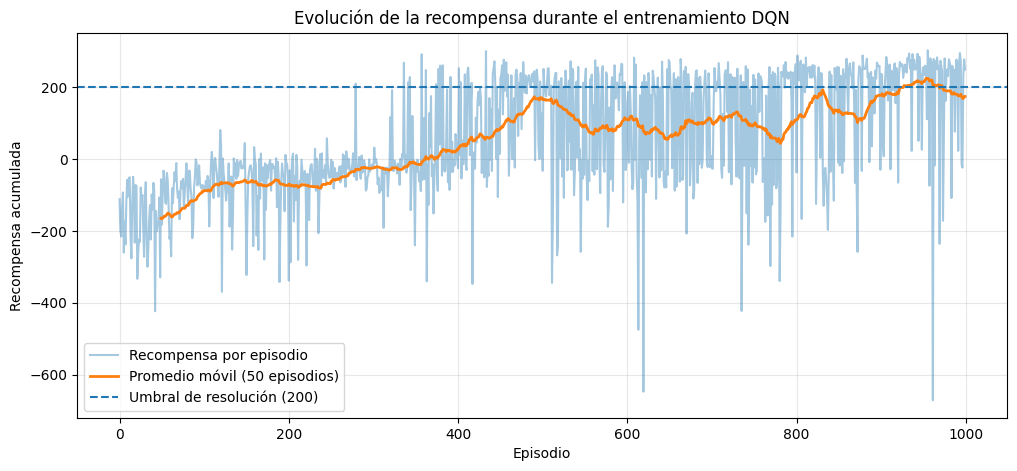

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(rewards_history, alpha=0.4, label="Recompensa por episodio")

# Promedio móvil de 50 episodios
moving_average = np.convolve(
    rewards_history,
    np.ones(50) / 50,
    mode="valid"
)

plt.plot(
    range(49, len(rewards_history)),
    moving_average,
    linewidth=2,
    label="Promedio móvil (50 episodios)"
)

plt.axhline(
    y=200,
    linestyle="--",
    label="Umbral de resolución (200)"
)

plt.xlabel("Episodio")
plt.ylabel("Recompensa acumulada")
plt.title("Evolución de la recompensa durante el entrenamiento DQN")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 8. Evaluación del agente

Una vez finalizado el entrenamiento, se evaluará el desempeño del agente utilizando varios episodios independientes.

Durante la evaluación no se realizará exploración aleatoria. El agente seleccionará en cada estado la acción con el mayor valor Q estimado por la red neuronal.

Se registrará la recompensa obtenida en cada episodio y se calcularán la recompensa promedio y su desviación estándar. Además, se verificará cuántos episodios alcanzan una recompensa igual o superior al umbral de resolución de 200.

In [21]:
def evaluate_agent(num_episodes=10):
    evaluation_rewards = []

    env = gym.make("LunarLander-v3")

    for episode in range(1, num_episodes + 1):

        state, info = env.reset(seed=episode)

        episode_reward = 0
        terminated = False
        truncated = False

        while not (terminated or truncated):

            # Selección determinista: explotación
            state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)

            with torch.no_grad():
                q_values = q_network(state_tensor)

            action = q_values.argmax(dim=1).item()

            # Ejecutar acción
            next_state, reward, terminated, truncated, info = env.step(action)

            state = next_state
            episode_reward += reward

        evaluation_rewards.append(episode_reward)

        print(
            f"Episodio {episode}: "
            f"Recompensa = {episode_reward:.2f}"
        )

    env.close()

    mean_reward = np.mean(evaluation_rewards)
    std_reward = np.std(evaluation_rewards)
    successful_episodes = sum(
        reward >= 200 for reward in evaluation_rewards
    )

    return (
        evaluation_rewards,
        mean_reward,
        std_reward,
        successful_episodes
    )

In [22]:
evaluation_rewards, mean_reward, std_reward, successful_episodes = evaluate_agent(
    num_episodes=10
)

print("\n--- RESULTADOS DE EVALUACIÓN ---")
print(f"Recompensa promedio: {mean_reward:.2f}")
print(f"Desviación estándar: {std_reward:.2f}")
print(f"Episodios con recompensa >= 200: {successful_episodes}/10")

Episodio 1: Recompensa = 249.90
Episodio 2: Recompensa = 236.40
Episodio 3: Recompensa = 248.18
Episodio 4: Recompensa = 268.62
Episodio 5: Recompensa = 199.61
Episodio 6: Recompensa = 149.52
Episodio 7: Recompensa = 264.21
Episodio 8: Recompensa = 267.92
Episodio 9: Recompensa = -61.87
Episodio 10: Recompensa = 256.50

--- RESULTADOS DE EVALUACIÓN ---
Recompensa promedio: 207.90
Desviación estándar: 96.58
Episodios con recompensa >= 200: 7/10


### 8.1 Evaluación ampliada

Para obtener una estimación más robusta del desempeño del agente, se realizará una evaluación sobre 100 episodios independientes.

Durante esta etapa no se realizará exploración aleatoria. El agente utilizará exclusivamente la política aprendida, seleccionando la acción con mayor valor Q en cada estado.

Se calcularán la recompensa promedio, la desviación estándar y el número de episodios que alcanzan una recompensa igual o superior a 200.

In [23]:
evaluation_rewards_100, mean_reward_100, std_reward_100, successful_episodes_100 = evaluate_agent(
    num_episodes=100
)

print("\n--- EVALUACIÓN FINAL (100 EPISODIOS) ---")
print(f"Recompensa promedio: {mean_reward_100:.2f}")
print(f"Desviación estándar: {std_reward_100:.2f}")
print(f"Episodios con recompensa >= 200: {successful_episodes_100}/100")

Episodio 1: Recompensa = 249.90
Episodio 2: Recompensa = 236.40
Episodio 3: Recompensa = 248.18
Episodio 4: Recompensa = 268.62
Episodio 5: Recompensa = 199.61
Episodio 6: Recompensa = 149.52
Episodio 7: Recompensa = 264.21
Episodio 8: Recompensa = 267.92
Episodio 9: Recompensa = -61.87
Episodio 10: Recompensa = 256.50
Episodio 11: Recompensa = 252.83
Episodio 12: Recompensa = 33.79
Episodio 13: Recompensa = 278.22
Episodio 14: Recompensa = 258.96
Episodio 15: Recompensa = 279.21
Episodio 16: Recompensa = 222.66
Episodio 17: Recompensa = 280.82
Episodio 18: Recompensa = 276.00
Episodio 19: Recompensa = 243.39
Episodio 20: Recompensa = 152.91
Episodio 21: Recompensa = 1.68
Episodio 22: Recompensa = 254.99
Episodio 23: Recompensa = 145.48
Episodio 24: Recompensa = 262.89
Episodio 25: Recompensa = 269.82
Episodio 26: Recompensa = -1.73
Episodio 27: Recompensa = 235.66
Episodio 28: Recompensa = 278.00
Episodio 29: Recompensa = -159.26
Episodio 30: Recompensa = 284.82
Episodio 31: Recompens

## 8.2 Distribución de recompensas durante la evaluación

La distribución de las recompensas obtenidas durante los 100 episodios de evaluación permite analizar la estabilidad del agente una vez finalizado el entrenamiento.

Además de la recompensa promedio, esta visualización permite identificar la variabilidad del desempeño y la cantidad de episodios que alcanzan el umbral de resolución establecido para el ambiente.

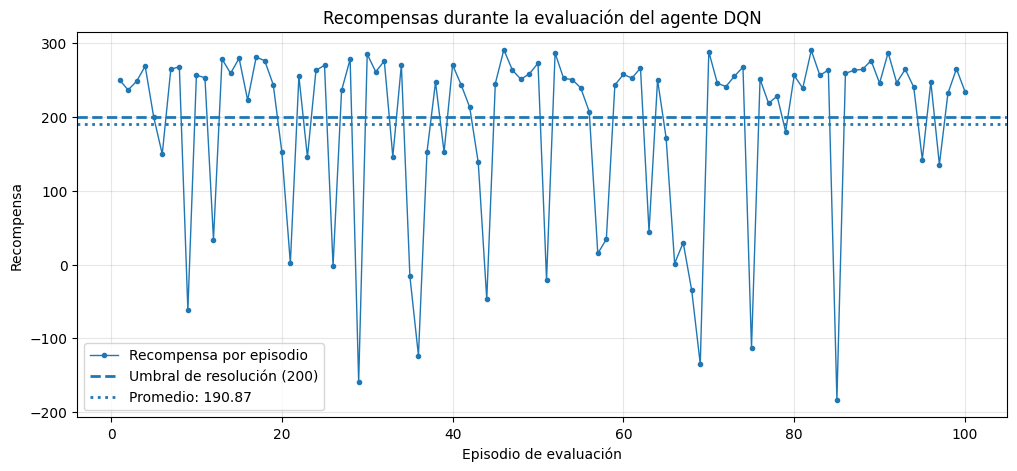

In [24]:
plt.figure(figsize=(12, 5))

plt.plot(
    range(1, 101),
    evaluation_rewards_100,
    marker="o",
    markersize=3,
    linewidth=1,
    label="Recompensa por episodio"
)

plt.axhline(
    y=200,
    linestyle="--",
    linewidth=2,
    label="Umbral de resolución (200)"
)

plt.axhline(
    y=mean_reward_100,
    linestyle=":",
    linewidth=2,
    label=f"Promedio: {mean_reward_100:.2f}"
)

plt.xlabel("Episodio de evaluación")
plt.ylabel("Recompensa")
plt.title("Recompensas durante la evaluación del agente DQN")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 9. Interpretación de los resultados

El entrenamiento durante 1.000 episodios permitió observar una mejora progresiva en el desempeño del agente. La recompensa pasó de valores predominantemente negativos durante las primeras etapas a valores positivos y superiores a 200 en diferentes momentos del entrenamiento.

La mejor recompensa obtenida durante el entrenamiento fue de **303.47**, mientras que la recompensa promedio considerando los 1.000 episodios fue de **53.26**.

En la evaluación independiente de 100 episodios, el agente obtuvo una recompensa promedio de **190.87**, con una desviación estándar de **118.31**. Además, **70 de los 100 episodios (70%)** alcanzaron una recompensa igual o superior a 200.

Estos resultados muestran que el agente logró aprender una política capaz de obtener un buen desempeño en una proporción importante de los episodios. Sin embargo, la variabilidad observada indica que el comportamiento todavía presenta cierta inestabilidad, especialmente en algunos episodios donde se obtuvieron recompensas bajas o negativas.

## 10. Dificultades encontradas

Una de las principales dificultades fue configurar correctamente todos los componentes necesarios para el funcionamiento del DQN, especialmente la interacción entre la Q-Network, la Target Network y el Replay Buffer.

También fue necesario controlar el equilibrio entre exploración y explotación mediante la política epsilon-greedy. Durante las primeras etapas del entrenamiento las recompensas fueron predominantemente negativas, por lo que fue necesario permitir suficiente exploración para que el agente pudiera aprender diferentes estrategias.

Otra dificultad fue la variabilidad propia del ambiente `LunarLander-v3`. Aunque el agente alcanzó recompensas superiores a 200 en numerosos episodios, también presentó algunos episodios con resultados negativos durante la evaluación. Esto evidencia que obtener una política efectiva no implica necesariamente que el comportamiento sea completamente estable en todos los episodios.

## 11. Conclusiones

La implementación permitió construir y entrenar exitosamente un agente Deep Q-Network para el ambiente `LunarLander-v3`.

El agente incorporó los principales componentes de un DQN: una red neuronal para aproximar la función Q, Replay Buffer, política epsilon-greedy, Target Network y actualización mediante la ecuación de Bellman.

Los resultados obtenidos evidencian un aprendizaje progresivo durante el entrenamiento. En la evaluación final de 100 episodios se obtuvo una recompensa promedio de **190.87** y un **70% de episodios con recompensa igual o superior a 200**.

Aunque el agente alcanzó un desempeño satisfactorio en una proporción importante de los episodios, la desviación estándar de **118.31** muestra que todavía existe variabilidad en su comportamiento. Como posibles mejoras se podrían explorar diferentes arquitecturas de red, tasas de aprendizaje, factores de descuento, estrategias de actualización de la Target Network y técnicas más avanzadas como Double DQN o Dueling DQN.